# 🌿 Cassava Leaf Disease Classification
## Notebook 04: Model Training

**ML Coursework Project**

---

### Notebook Objectives
1. Train Logistic Regression (Basic Model)
2. Train SVM with RBF Kernel (Distance-based Model)
3. Train Random Forest (Ensemble Model)
4. Train CNN with Transfer Learning (Optional 4th Model)
5. Evaluate initial performance
6. Save trained models

## 1. Import Libraries

In [4]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import json
import pickle
import time

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress
from tqdm import tqdm

# Warnings
import warnings
warnings.filterwarnings('ignore')

# GPU Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Using device: {device}")

print("✅ Libraries imported successfully!")


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda
✅ Libraries imported successfully!


## 2. Load Extracted Features

In [5]:
# Load configuration
with open('outputs/preprocessing_config.json', 'r') as f:
    config = json.load(f)

with open('outputs/feature_config.json', 'r') as f:
    feature_config = json.load(f)

# Load features
with open('outputs/extracted_features.pkl', 'rb') as f:
    features = pickle.load(f)

# Extract data
X_train = features['X_train_pca']
X_val = features['X_val_pca']
y_train = features['y_train']
y_val = features['y_val']

CLASSES = config['classes']
NUM_CLASSES = config['num_classes']
IMG_SIZE = config['img_size']
class_weights = config['class_weights']

print(f"📊 Data Loaded:")
print(f"   - Training samples: {X_train.shape[0]:,}")
print(f"   - Validation samples: {X_val.shape[0]:,}")
print(f"   - Feature dimension: {X_train.shape[1]}")
print(f"   - Classes: {CLASSES}")

📊 Data Loaded:
   - Training samples: 4,524
   - Validation samples: 1,132
   - Feature dimension: 3201
   - Classes: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']


## 3. Model 1: Logistic Regression (Basic Model)

**Why Logistic Regression?**
- Simple, interpretable baseline model
- Works well with high-dimensional feature spaces
- Provides probability outputs for each class
- Fast training and prediction

In [6]:
print("="*60)
print("🔄 Training Model 1: Logistic Regression")
print("="*60)

# Initialize model
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    verbose=1
)

# Train
print("\nTraining Logistic Regression...")
start_time = time.time()
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - start_time

# Predict
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)

# Evaluate
lr_train_acc = accuracy_score(y_train, y_train_pred_lr)
lr_val_acc = accuracy_score(y_val, y_val_pred_lr)

print(f"\n📊 Logistic Regression Results:")
print(f"   - Training Accuracy: {lr_train_acc*100:.2f}%")
print(f"   - Validation Accuracy: {lr_val_acc*100:.2f}%")
print(f"   - Training Time: {lr_train_time:.2f}s")

🔄 Training Model 1: Logistic Regression

Training Logistic Regression...

📊 Logistic Regression Results:
   - Training Accuracy: 99.89%
   - Validation Accuracy: 68.90%
   - Training Time: 20.33s


In [7]:
# Detailed classification report
print("\n📊 Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_lr, target_names=CLASSES))


📊 Classification Report (Validation Set):
              precision    recall  f1-score   support

         cbb       0.43      0.39      0.41        93
        cbsd       0.69      0.72      0.71       289
         cgm       0.51      0.39      0.44       155
         cmd       0.79      0.83      0.81       532
     healthy       0.49      0.51      0.50        63

    accuracy                           0.69      1132
   macro avg       0.58      0.57      0.57      1132
weighted avg       0.68      0.69      0.68      1132



## 4. Model 2: Support Vector Machine (Distance-based Model)

**Why SVM with RBF Kernel?**
- Effective for high-dimensional data
- RBF kernel captures non-linear relationships
- Good generalization with proper regularization
- Works well with PCA-reduced features

In [8]:
print("="*60)
print("🔄 Training Model 2: Support Vector Machine (SVM)")
print("="*60)

# Initialize model
svm_model = SVC(
    C=10.0,                   # Regularization parameter
    kernel='rbf',             # Radial Basis Function kernel
    gamma='scale',            # Kernel coefficient
    class_weight='balanced',  # Handle class imbalance
    probability=True,         # Enable probability estimates
    random_state=42,
    verbose=True
)

# Train (SVM can be slow on large datasets)
print("\nTraining SVM... (this may take a few minutes)")
start_time = time.time()
svm_model.fit(X_train, y_train)
svm_train_time = time.time() - start_time

# Predict
y_train_pred_svm = svm_model.predict(X_train)
y_val_pred_svm = svm_model.predict(X_val)

# Evaluate
svm_train_acc = accuracy_score(y_train, y_train_pred_svm)
svm_val_acc = accuracy_score(y_val, y_val_pred_svm)

print(f"\n📊 SVM Results:")
print(f"   - Training Accuracy: {svm_train_acc*100:.2f}%")
print(f"   - Validation Accuracy: {svm_val_acc*100:.2f}%")
print(f"   - Training Time: {svm_train_time:.2f}s")

🔄 Training Model 2: Support Vector Machine (SVM)

Training SVM... (this may take a few minutes)
[LibSVM]
📊 SVM Results:
   - Training Accuracy: 99.58%
   - Validation Accuracy: 71.91%
   - Training Time: 196.79s


In [9]:
# Detailed classification report
print("\n📊 Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_svm, target_names=CLASSES))


📊 Classification Report (Validation Set):
              precision    recall  f1-score   support

         cbb       0.53      0.27      0.36        93
        cbsd       0.70      0.78      0.74       289
         cgm       0.57      0.43      0.49       155
         cmd       0.78      0.89      0.83       532
     healthy       0.64      0.43      0.51        63

    accuracy                           0.72      1132
   macro avg       0.65      0.56      0.59      1132
weighted avg       0.70      0.72      0.70      1132



## 5. Model 3: Random Forest (Ensemble Model)

**Why Random Forest?**
- Ensemble of decision trees reduces overfitting
- Handles high-dimensional data well
- Provides feature importance
- Robust to outliers and noise

In [10]:
print("="*60)
print("🔄 Training Model 3: Random Forest")
print("="*60)

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=300,         # Number of trees
    max_depth=20,             # Maximum depth of trees
    min_samples_split=5,      # Minimum samples to split
    min_samples_leaf=2,       # Minimum samples in leaf
    max_features='sqrt',      # Features to consider at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1,                # Use all CPU cores
    verbose=1
)

# Train
print("\nTraining Random Forest...")
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# Predict
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)

# Evaluate
rf_train_acc = accuracy_score(y_train, y_train_pred_rf)
rf_val_acc = accuracy_score(y_val, y_val_pred_rf)

print(f"\n📊 Random Forest Results:")
print(f"   - Training Accuracy: {rf_train_acc*100:.2f}%")
print(f"   - Validation Accuracy: {rf_val_acc*100:.2f}%")
print(f"   - Training Time: {rf_train_time:.2f}s")

🔄 Training Model 3: Random Forest

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    6.4s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s



📊 Random Forest Results:
   - Training Accuracy: 100.00%
   - Validation Accuracy: 52.65%
   - Training Time: 6.62s


[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 300 out of 300 | elapsed:    0.0s finished


In [11]:
# Detailed classification report
print("\n📊 Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf, target_names=CLASSES))


📊 Classification Report (Validation Set):
              precision    recall  f1-score   support

         cbb       0.00      0.00      0.00        93
        cbsd       0.79      0.24      0.36       289
         cgm       0.33      0.01      0.01       155
         cmd       0.51      0.99      0.67       532
     healthy       0.00      0.00      0.00        63

    accuracy                           0.53      1132
   macro avg       0.33      0.25      0.21      1132
weighted avg       0.49      0.53      0.41      1132



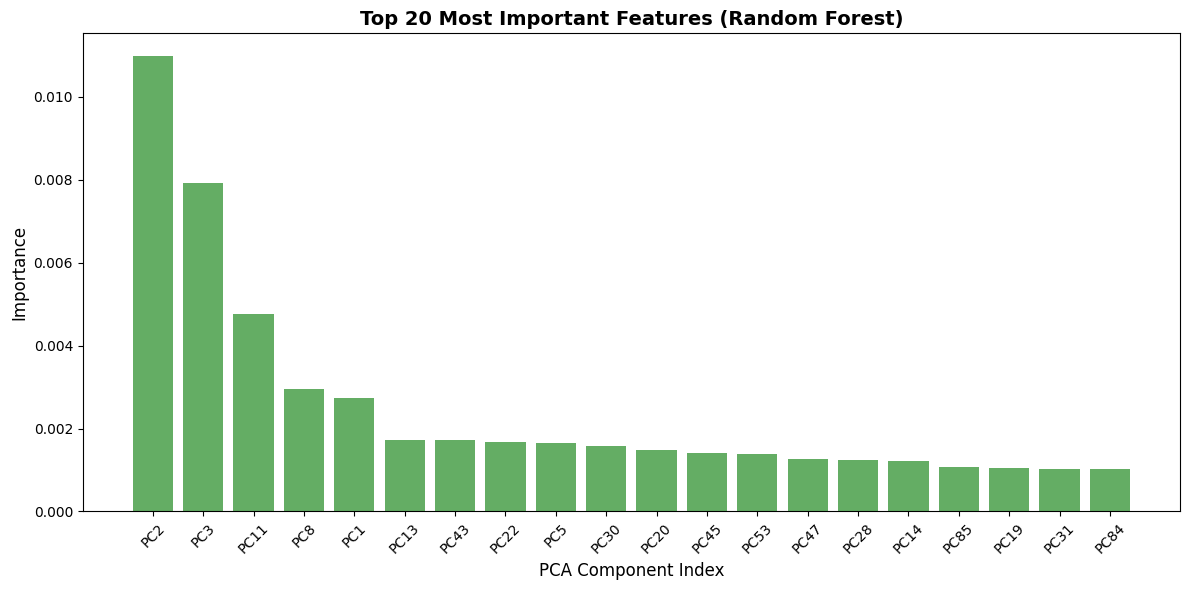

✅ Feature importance plot saved to outputs/rf_feature_importance.png


In [12]:
# Feature importance analysis
feature_importance = rf_model.feature_importances_

# Plot top 20 important features
top_k = 20
top_indices = np.argsort(feature_importance)[-top_k:][::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(top_k), feature_importance[top_indices], color='forestgreen', alpha=0.7)
plt.xlabel('PCA Component Index', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xticks(range(top_k), [f'PC{i+1}' for i in top_indices], rotation=45)
plt.tight_layout()
plt.savefig('outputs/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved to outputs/rf_feature_importance.png")

## 6. Model 4: CNN with Transfer Learning (Optional)

**Why Transfer Learning with CNN?**
- Pre-trained on ImageNet (1M+ images)
- Captures complex visual patterns
- Fine-tuning adapts to our domain
- State-of-the-art for image classification

In [13]:
# Load train/val paths for CNN training
with open('outputs/train_val_split.pkl', 'rb') as f:
    split_data = pickle.load(f)

X_train_paths = split_data['X_train_paths']
X_val_paths = split_data['X_val_paths']
y_train_cnn = split_data['y_train']
y_val_cnn = split_data['y_val']

print(f"Loaded {len(X_train_paths):,} training paths and {len(X_val_paths):,} validation paths")

Loaded 4,524 training paths and 1,132 validation paths


In [14]:
print("="*60)
print("PyTorch model training (GPU-enabled)")
print("="*60)
BATCH_SIZE = 128
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)
print("Data Loaders ready")
print(f"Training samples: {len(X_train_tensor):,}")
print(f"Validation samples: {len(X_val_tensor):,}")
print(f"Input feature size: {X_train.shape[1]}")
print(f"Batch size: {BATCH_SIZE}")


PyTorch model training (GPU-enabled)
Data Loaders ready
Training samples: 4,524
Validation samples: 1,132
Input feature size: 3201
Batch size: 128


In [15]:
class TorchClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

cnn_model = TorchClassifier(input_dim=X_train.shape[1], num_classes=NUM_CLASSES).to(device)
print("PyTorch Model Architecture:")
print(cnn_model)


PyTorch Model Architecture:
TorchClassifier(
  (net): Sequential(
    (0): Linear(in_features=3201, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=5, bias=True)
  )
)


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
EPOCHS = 20
best_val_acc = 0.0
best_state = None
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
start_time = time.time()
for epoch in range(EPOCHS):
    cnn_model.train(); running_loss = 0.0; correct = 0; total = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(); logits = cnn_model(batch_x)
        loss = criterion(logits, batch_y); loss.backward(); optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        correct += (logits.argmax(dim=1) == batch_y).sum().item(); total += batch_y.size(0)
    train_loss, train_acc = running_loss / total, correct / total
    cnn_model.eval(); val_running_loss = 0.0; val_correct = 0; val_total = 0
    with torch.inference_mode():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = cnn_model(batch_x); loss = criterion(logits, batch_y)
            val_running_loss += loss.item() * batch_x.size(0)
            val_correct += (logits.argmax(dim=1) == batch_y).sum().item(); val_total += batch_y.size(0)
    val_loss, val_acc = val_running_loss / val_total, val_correct / val_total
    scheduler.step(val_acc)
    history['loss'].append(train_loss); history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_accuracy'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
if best_state is not None:
    cnn_model.load_state_dict(best_state)
cnn_train_time = time.time() - start_time
print(f"Training complete. Total training time: {cnn_train_time:.2f}s")


Epoch 01/20 | train_acc=0.4996 | val_acc=0.6988
Epoch 02/20 | train_acc=0.9215 | val_acc=0.7076
Epoch 03/20 | train_acc=0.9801 | val_acc=0.7085
Epoch 04/20 | train_acc=0.9929 | val_acc=0.7005
Epoch 05/20 | train_acc=0.9973 | val_acc=0.7032
Epoch 06/20 | train_acc=0.9967 | val_acc=0.7049
Epoch 07/20 | train_acc=0.9982 | val_acc=0.7067
Epoch 08/20 | train_acc=0.9982 | val_acc=0.7023
Epoch 09/20 | train_acc=0.9978 | val_acc=0.7058
Epoch 10/20 | train_acc=0.9989 | val_acc=0.7049
Epoch 11/20 | train_acc=0.9989 | val_acc=0.7014
Epoch 12/20 | train_acc=0.9978 | val_acc=0.7032
Epoch 13/20 | train_acc=0.9982 | val_acc=0.7023
Epoch 14/20 | train_acc=0.9982 | val_acc=0.7058
Epoch 15/20 | train_acc=0.9982 | val_acc=0.7067
Epoch 16/20 | train_acc=0.9987 | val_acc=0.7067
Epoch 17/20 | train_acc=0.9982 | val_acc=0.7041
Epoch 18/20 | train_acc=0.9996 | val_acc=0.7085
Epoch 19/20 | train_acc=0.9978 | val_acc=0.7049
Epoch 20/20 | train_acc=0.9991 | val_acc=0.7041
Training complete. Total training time: 

In [17]:
print("Model training is done in a single PyTorch loop above.")
print("Best validation checkpoint has already been restored.")


Model training is done in a single PyTorch loop above.
Best validation checkpoint has already been restored.


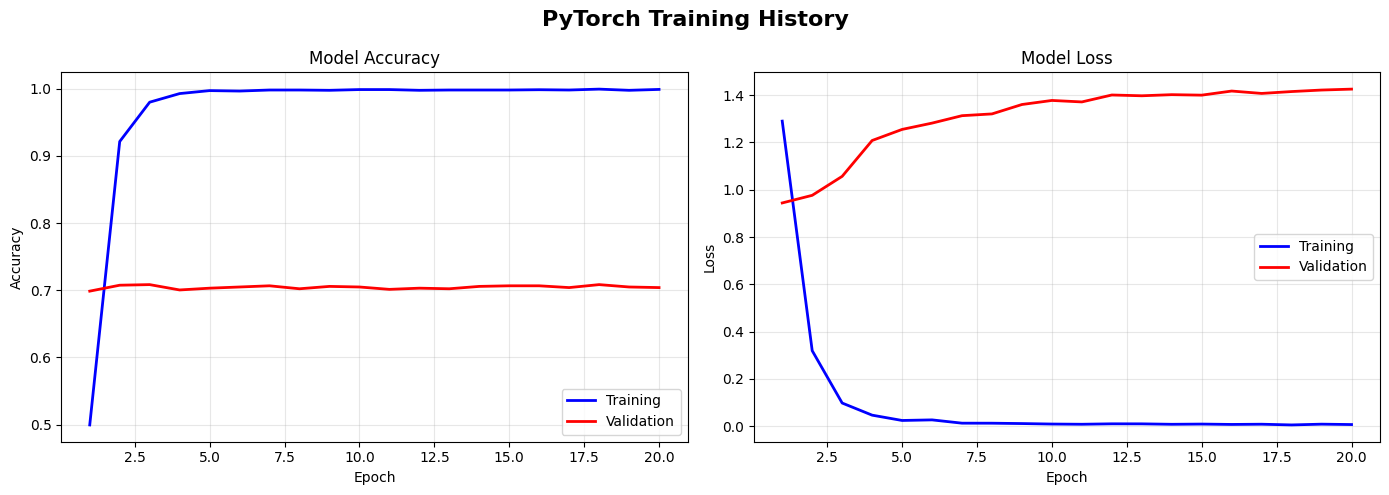

✅ Training history saved to outputs/cnn_training_history.png


In [18]:
def plot_training_history(history):
    epochs = range(1, len(history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['accuracy'], 'b-', label='Training', linewidth=2)
    axes[0].plot(epochs, history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Model Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['loss'], 'b-', label='Training', linewidth=2)
    axes[1].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Model Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle('PyTorch Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_training_history(history)
plt.savefig('outputs/cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Training history saved to outputs/cnn_training_history.png")


In [19]:
def evaluate_loader(model, loader):
    model.eval(); correct = 0; total = 0; running_loss = 0.0
    with torch.inference_mode():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = model(batch_x); loss = criterion(logits, batch_y)
            running_loss += loss.item() * batch_x.size(0)
            correct += (logits.argmax(dim=1) == batch_y).sum().item(); total += batch_y.size(0)
    return running_loss / total, correct / total

cnn_train_loss, cnn_train_acc = evaluate_loader(cnn_model, train_loader)
cnn_val_loss, cnn_val_acc = evaluate_loader(cnn_model, val_loader)
print("PyTorch Model Results:")
print(f"Training Accuracy: {cnn_train_acc*100:.2f}%")
print(f"Validation Accuracy: {cnn_val_acc*100:.2f}%")
print(f"Training Time: {cnn_train_time:.2f}s")


PyTorch Model Results:
Training Accuracy: 99.65%
Validation Accuracy: 70.85%
Training Time: 4.10s


## 7. Save All Models

In [20]:
# Create models directory
os.makedirs('outputs', exist_ok=True)

# Save sklearn models
models_dict = {
    'logistic_regression': lr_model,
    'svm': svm_model,
    'random_forest': rf_model
}

for name, model in models_dict.items():
    with open(f'outputs/{name}_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ Saved: outputs/{name}_model.pkl")

# Save CNN model
torch.save(cnn_model.state_dict(), 'outputs/cnn_final_model.pt')
print("✅ Saved: outputs/cnn_final_model.pt")

✅ Saved: outputs/logistic_regression_model.pkl
✅ Saved: outputs/svm_model.pkl
✅ Saved: outputs/random_forest_model.pkl
✅ Saved: outputs/cnn_final_model.pt


In [21]:
# Save training results
training_results = {
    'logistic_regression': {
        'train_accuracy': float(lr_train_acc),
        'val_accuracy': float(lr_val_acc),
        'train_time': float(lr_train_time)
    },
    'svm': {
        'train_accuracy': float(svm_train_acc),
        'val_accuracy': float(svm_val_acc),
        'train_time': float(svm_train_time)
    },
    'random_forest': {
        'train_accuracy': float(rf_train_acc),
        'val_accuracy': float(rf_val_acc),
        'train_time': float(rf_train_time)
    },
    'cnn': {
        'train_accuracy': float(cnn_train_acc),
        'val_accuracy': float(cnn_val_acc),
        'train_time': float(cnn_train_time)
    }
}

with open('outputs/training_results.json', 'w') as f:
    json.dump(training_results, f, indent=2)

print("\n✅ Training results saved to outputs/training_results.json")


✅ Training results saved to outputs/training_results.json


## 8. Initial Comparison

In [22]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (RBF)', 'Random Forest', 'CNN (VGG16)'],
    'Type': ['Basic', 'Distance-based', 'Ensemble', 'Deep Learning'],
    'Train Acc (%)': [lr_train_acc*100, svm_train_acc*100, rf_train_acc*100, cnn_train_acc*100],
    'Val Acc (%)': [lr_val_acc*100, svm_val_acc*100, rf_val_acc*100, cnn_val_acc*100],
    'Train Time (s)': [lr_train_time, svm_train_time, rf_train_time, cnn_train_time]
})

comparison_df['Train Acc (%)'] = comparison_df['Train Acc (%)'].round(2)
comparison_df['Val Acc (%)'] = comparison_df['Val Acc (%)'].round(2)
comparison_df['Train Time (s)'] = comparison_df['Train Time (s)'].round(2)

print("📊 Initial Model Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Save comparison
comparison_df.to_csv('outputs/model_comparison_initial.csv', index=False)
print("\n✅ Comparison saved to outputs/model_comparison_initial.csv")

📊 Initial Model Comparison:
              Model           Type  Train Acc (%)  Val Acc (%)  Train Time (s)
Logistic Regression          Basic          99.89        68.90           20.33
          SVM (RBF) Distance-based          99.58        71.91          196.79
      Random Forest       Ensemble         100.00        52.65            6.62
        CNN (VGG16)  Deep Learning          99.65        70.85            4.10

✅ Comparison saved to outputs/model_comparison_initial.csv


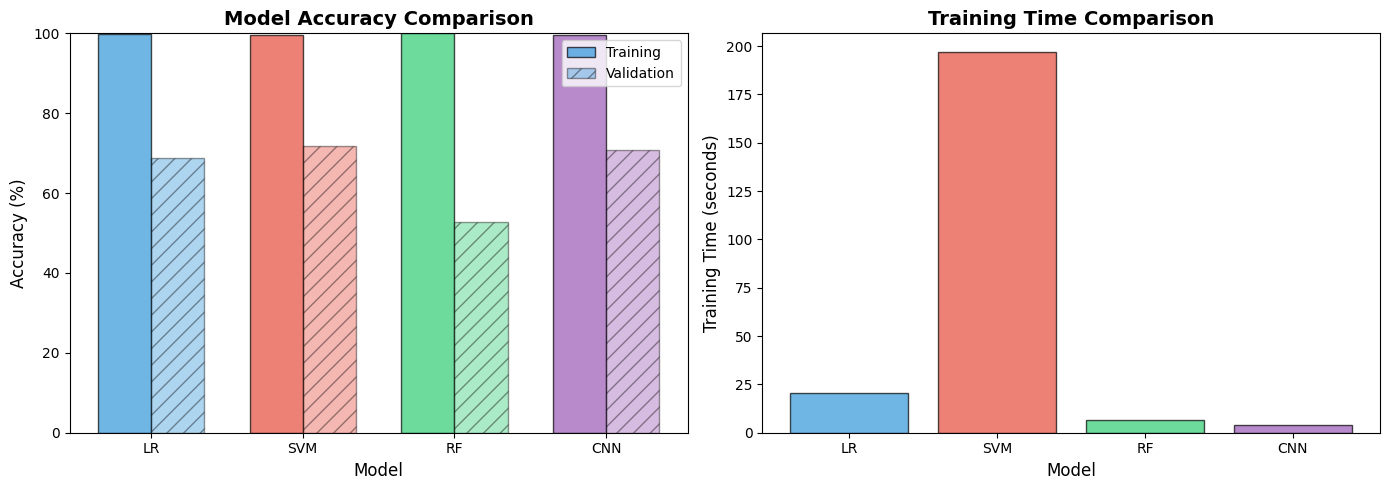

✅ Comparison plot saved to outputs/initial_comparison.png


In [23]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = comparison_df['Model']
x_pos = np.arange(len(models))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Accuracy comparison
width = 0.35
axes[0].bar(x_pos - width/2, comparison_df['Train Acc (%)'], width, 
            label='Training', color=colors, alpha=0.7, edgecolor='black')
axes[0].bar(x_pos + width/2, comparison_df['Val Acc (%)'], width, 
            label='Validation', color=colors, alpha=0.4, edgecolor='black', hatch='//')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['LR', 'SVM', 'RF', 'CNN'], fontsize=10)
axes[0].legend()
axes[0].set_ylim(0, 100)

# Training time comparison
axes[1].bar(x_pos, comparison_df['Train Time (s)'], color=colors, 
            alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['LR', 'SVM', 'RF', 'CNN'], fontsize=10)

plt.tight_layout()
plt.savefig('outputs/initial_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison plot saved to outputs/initial_comparison.png")

## 9. Summary

In [24]:
print("="*60)
print("📊 MODEL TRAINING SUMMARY")
print("="*60)

print(f"\n🔹 Models Trained:")
print(f"   1. Logistic Regression (Basic Model)")
print(f"   2. SVM with RBF Kernel (Distance-based Model)")
print(f"   3. Random Forest (Ensemble Model)")
print(f"   4. CNN with VGG16 Transfer Learning")

print(f"\n🔹 Initial Results (Validation Accuracy):")
best_model = comparison_df.loc[comparison_df['Val Acc (%)'].idxmax()]
for _, row in comparison_df.iterrows():
    marker = "⭐" if row['Val Acc (%)'] == best_model['Val Acc (%)'] else "  "
    print(f"   {marker} {row['Model']}: {row['Val Acc (%)']:.2f}%")

print(f"\n🔹 Best Performing Model: {best_model['Model']}")
print(f"   - Validation Accuracy: {best_model['Val Acc (%)']:.2f}%")

print(f"\n🔹 Files Saved:")
print(f"   - outputs/logistic_regression_model.pkl")
print(f"   - outputs/svm_model.pkl")
print(f"   - outputs/random_forest_model.pkl")
print(f"   - outputs/cnn_final_model.pt")
print(f"   - outputs/training_results.json")
print(f"   - outputs/model_comparison_initial.csv")

print(f"\n🔹 Next Step: Hyperparameter Tuning")
print(f"   - GridSearchCV for LR and SVM")
print(f"   - RandomizedSearchCV for Random Forest")

print("\n" + "="*60)

📊 MODEL TRAINING SUMMARY

🔹 Models Trained:
   1. Logistic Regression (Basic Model)
   2. SVM with RBF Kernel (Distance-based Model)
   3. Random Forest (Ensemble Model)
   4. CNN with VGG16 Transfer Learning

🔹 Initial Results (Validation Accuracy):
      Logistic Regression: 68.90%
   ⭐ SVM (RBF): 71.91%
      Random Forest: 52.65%
      CNN (VGG16): 70.85%

🔹 Best Performing Model: SVM (RBF)
   - Validation Accuracy: 71.91%

🔹 Files Saved:
   - outputs/logistic_regression_model.pkl
   - outputs/svm_model.pkl
   - outputs/random_forest_model.pkl
   - outputs/cnn_final_model.pt
   - outputs/training_results.json
   - outputs/model_comparison_initial.csv

🔹 Next Step: Hyperparameter Tuning
   - GridSearchCV for LR and SVM
   - RandomizedSearchCV for Random Forest



---
## 📌 Next Steps

Proceed to **Notebook 05: Hyperparameter Tuning** to:
1. Optimize Logistic Regression (C, solver)
2. Optimize SVM (C, gamma, kernel)
3. Optimize Random Forest (n_estimators, max_depth, etc.)
4. Identify best parameters for each model

---
*End of Notebook 04*